In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import math

In [2]:
# device
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(device)

cuda


In [4]:
# variables
T = 1500 # timesteps
img_size = 28 # FashionMNIST
batch_size = 128
epochs = 20
lr = 1e-3
base_channels = 64 # base channels used for U-Net

In [4]:
# importing dataset

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x*2 - 1)    # Changing range from (0, 1) to (-1, 1)
])

train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [ ]:
import torch
batch_size = 128
unet_pred_noise = torch.randn((batch_size, 1, 28, 28))
betas = torch.linspace(1e-4, 0.02, 1000)    # [1000]
print(f"betas shape: {betas.shape}")
t = torch.tensor([10]).expand(batch_size)
print(f"t shape: {t.shape}")
print(betas[t])
print(f"betas[t] shape: {betas[t].shape}")

betas shape: torch.Size([1000])
t shape: torch.Size([128])
tensor([0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003,
        0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003,
        0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003,
        0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003,
        0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003,
        0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003,
        0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003,
        0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003,
        0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003,
        0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003,
        0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003,
        0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.000

In [5]:
class LinearNoiseScheduler:
    def __init__(self, num_timesteps, beta_start, beta_end):
        self.num_timesteps = num_timesteps
        self.beta_start = beta_start
        self.beta_end = beta_end

        # All these tensors have dimension --> [1000] if num_timesteps = 1000
        self.betas = torch.linspace(beta_start, beta_end, num_timesteps)
        self.alphas = 1. - self.betas
        self.alpha_bars = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alpha_bars = torch.sqrt(self.alpha_bars)
        self.sqrt_one_minus_alpha_bars = torch.sqrt(1. - self.alpha_bars)

    def add_noise(self, x_0, noise, t):
        # sqrt_alpha_bars[t] has shape [batch_size] and we need to multiply it with [batch_size, 1, 28, 28] image.
        # for broadcasting to work correctly, we are adding dimensions to make it [batch_size, 1, 1, 1]
        sqrt_alpha_bars = self.sqrt_alpha_bars[t].reshape([-1, 1, 1, 1]).to(x_0.device)   # Bx1x1x1
        sqrt_one_minus_alpha_bars = self.sqrt_one_minus_alpha_bars[t].reshape([-1, 1, 1, 1]).to(x_0.device)   # Bx1x1x1

        # the direct formula to get x_t from x_0
        return sqrt_alpha_bars*x_0 + sqrt_one_minus_alpha_bars*noise

torch.Size([6, 1, 28, 28])
torch.Size([1, 28, 28])


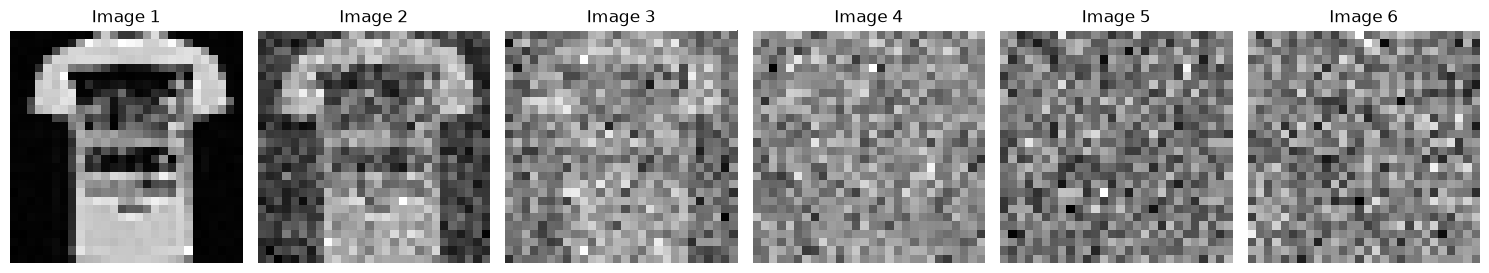

In [6]:
# testing add_noise on image from dataset
train_img, train_label = next(iter(train_loader))
train_img.shape, train_label.shape

test_img = train_img[0]
test_img_batched = torch.stack([test_img for _ in range(6)], dim=0)
print(test_img_batched.shape)
noise = torch.randn_like(test_img_batched)
t = [0, 100, 250, 500, 750, 999]

lns = LinearNoiseScheduler(1000, 1e-4, 0.02)
out_imgs = lns.add_noise(test_img_batched, noise=noise, t=t)
out_imgs = (out_imgs + 1)/2
print(out_imgs[1].shape)

fig, axes = plt.subplots(nrows=1, ncols=6, figsize=(15, 3))
for i in range(6):
    img = out_imgs[i].squeeze()
    img_numpy = img.cpu().numpy()

    axes[i].imshow(img_numpy, cmap="gray")
    axes[i].set_title(f"Image {i+1}")
    axes[i].axis("off") # Hide the grid and the pixel coordinates
plt.tight_layout()
plt.show()

In [7]:
import torch
B = 128
TDIM = 128
time_steps = torch.randint(1, 1000, (B,))   # timesteps for each image in batch
frequencies = 1 / (10000 ** torch.arange(start=0, end=TDIM//2, device=time_steps.device) / (TDIM // 2)) # [t_emb_dim // 2, ]
args = time_steps.unsqueeze(1) * frequencies.unsqueeze(0)   # [B, t_emb_dim // 2]
sin_emb = torch.sin(args)   # [B, t_emb_dim // 2]
cos_emb = torch.cos(args)   # [B, t_emb_dim // 2]
emb = torch.stack((sin_emb, cos_emb), dim=2)    # [B, t_emb_dim // 2, 2]
emb = emb.reshape((time_steps.shape[0], -1))    # [B, t_emb_dim]

In [8]:
t1 = torch.randn((128, 64))
t2 = torch.randn((128, 64))

# combine - 
torch.stack((t1, t2), dim=2)

tensor([[[ 0.5135,  0.5091],
         [-0.1172,  0.2314],
         [-1.0913,  0.2233],
         ...,
         [ 0.9388, -0.5777],
         [ 0.6216, -2.0314],
         [-1.1312,  0.9173]],

        [[-1.5111, -0.1071],
         [-1.0541,  0.5142],
         [ 0.1653,  2.8206],
         ...,
         [-0.6272, -0.5164],
         [ 0.7983, -0.7938],
         [-1.7819,  0.9000]],

        [[ 0.4627, -1.4629],
         [-1.4190,  0.3798],
         [-0.0360,  0.6613],
         ...,
         [-0.1863, -0.6706],
         [ 1.9669,  1.1578],
         [ 0.9873, -0.1289]],

        ...,

        [[ 0.7795, -0.9898],
         [ 0.3782,  0.0261],
         [-0.7207, -1.5547],
         ...,
         [-2.4022,  0.7008],
         [ 0.4120,  0.0994],
         [-0.4991, -0.9069]],

        [[-0.5603, -0.2452],
         [-1.1769,  0.6275],
         [ 0.5958, -0.1717],
         ...,
         [-1.6838,  2.3188],
         [-0.2164, -0.3941],
         [-0.8749,  1.0747]],

        [[-0.2068,  1.8495],
       

In [1]:
def sinusoidal_time_embedding(time_steps, t_emb_dim):
        """
            The even odd rule is for the dimension index i and not the timestep t.
            for each timestep t, we calculate the sin and cos in alternate manner
            pos 0 gets sin, pos 1 gets cos, pos 2 gets sin, pos 3 gets cos ... 
            the formula is - sin(t / 10000^(2i/d_model))
            Inputs:|
                time_steps: Batched integer timesteps for images of shape [B,]
                t_emb_dim: The dimension of generated embeddings
            Outputs:
                emb: batched embedding for input timesteps, has shape [B, t_emb_dim]
        """
        # Since the argument inside the sin or cos function --> (t / 10000^(2i/d_model))
        # is basically just (t * frequency). We already have t so we need to calculate frequency part that depends on i.
        frequencies = 1 / (10000 ** (torch.arange(start=0, end=t_emb_dim//2, device=time_steps.device) / (t_emb_dim // 2)))   # Shape [t_emb_dim/2, ]

        # Now we multiply the frequencies with time_steps t. [B, ] x [t_emb_dim/2, ]
        args = time_steps.unsqueeze(1) * frequencies.unsqueeze(0)

        # Now applying sin and cos
        sin_emb = torch.sin(args)
        cos_emb = torch.cos(args)

        # Now need to join these in alternating manner (sin cos sin cos ...)
        emb = torch.stack((sin_emb, cos_emb), dim=2).reshape((time_steps.shape[0], -1))

        return emb

In [2]:
import torch
import torch.nn as nn

class ResBlock(nn.Module):

    def __init__(self, in_channels, out_channels, t_emb_dim):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.t_emb_dim = t_emb_dim
        
        self.act = nn.SiLU()
        
        # To map sinusoidal time embedding to out_channels
        self.lin = nn.Linear(self.t_emb_dim, self.out_channels)
        # Define First Conv Group
        self.norm1 = nn.GroupNorm(8, self.in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1)
        # Define Second Conv Group
        self.norm2 = nn.GroupNorm(8, self.out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        # For shortcut connection
        if in_channels != out_channels:
            self.linearProj = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0)
        else:
            self.linearProj = nn.Identity()

    def forward(self, x, time_emb):
        time_emb = self.lin(self.act(time_emb))
        x1 = self.conv1(self.act(self.norm1(x)))   # First conv step complete
        x1 = x1 + time_emb[..., None, None]        # Time embedding injection complete
        x2 = self.conv2(self.act(self.norm2(x1)))  # Second conv step complete
        x2 = x2 + self.linearProj(x)               # Shortcut connection complete
        return self.act(x2)



In [6]:
# testing 
time_emb_dim = 128
time_steps = torch.randint(1, 1500, (batch_size, ))
time_emb = sinusoidal_time_embedding(time_steps, time_emb_dim)
fake_imgs = torch.randn((batch_size, base_channels, 28, 28))
res1 = ResBlock(base_channels, 128, time_emb_dim)
output = res1(fake_imgs, time_emb)
output.shape

torch.Size([128, 128, 28, 28])

In [ ]:
fmap = torch.randn((128, 256, 7, 7))
torch.flatten(fmap, start_dim=2, end_dim=-1).shape

torch.Size([128, 256, 49])

In [ ]:
class AttentionBlock(nn.Module):

    def __init__(self, input_dim, qkv_dim, n_heads):
        """Takes in feature maps of shape (B, C, H, W) converts to (B, C, H*W) then H*W part acts as sequence length
        and number of channels act as embedding dimension for the input to the attention mechanism. It applies multi-head attention
        to our batch and returns outputs in (B, C, H, W) format again.
        Args:
            input_dim: Number of channels/feature_maps in input img (acts as input_dim before we convert to qkv)
            qkv_dim: This is basically d_model or the dimension of Q, K, V
            n_heads: Number of heads in multi-head self attn
        """
        super().__init__()
        self.input_dim = input_dim
        self.qkv_dim = qkv_dim
        self.n_heads = n_heads
        self.head_dim = qkv_dim // n_heads
        self.qkv_proj = nn.Linear(input_dim, qkv_dim * 3) # Converting to Q, K, V in single linear layer for efficiency
        self.final_proj = nn.Linear(qkv_dim, input_dim)
        self.norm = nn.GroupNorm(8, input_dim)

    def scaled_dot_product(self, q, k, v):
        # Softmax(((q @ k_T) // d_k) @ v)
        # Inputs are -> [B, n_heads, seq_len(H*W), head_dim]
        sqrt_d_k = math.sqrt(q.shape[-1])
        scaled = q @ k.transpose(-1, -2) / sqrt_d_k # [B, n_heads, seq_len, head_dim] @ [B, n_heads, head_dim, seq_len] --> [B, n_heads, seq_len, seq_len]        
        attn_score = torch.softmax(scaled, dim=-1)  #[B, n_heads, seq_len, seq_len]
        return attn_score @ v   # [B, n_heads, seq_len, seq_len] @ [B, n_heads, seq_len, head_dim] --> [B, n_heads, seq_len, head_dim]


    def forward(self, fmap):
        # reshape from [B, C, H, W] to [B, C(input_dim), H*W (seq_len)]
        seq = torch.flatten(self.norm(fmap), start_dim=2, end_dim=-1).permute(0, 2, 1)  # [B, seq_len(H*W), input_dim(C)]
        B, seq_len, _ = seq.shape
        qkv = self.qkv_proj(seq)   # [B, seq_len, input_dim] -> [B, seq_len, qkv_dim * 3]
        qkv = qkv.reshape(B, seq_len, self.n_heads, 3 * self.head_dim) # [B, seq_len, n_heads, 3 * head dim]
        qkv = qkv.permute(0, 2, 1, 3)   # [B, n_heads, seq_len, 3 * head_dim]
        q, k, v = qkv.chunk(3, dim=-1)  # Q, K, V have shape [B, n_heads, seq_len, head_dim]
        # Calculate attn
        out = self.scaled_dot_product(q, k, v)  # [B, n_heads, seq_len, head_dim]
        # Combine all heads
        out = out.permute(0, 2, 1, 3)   # [B, seq_len, n_heads, head_dim]
        out = out.reshape(B, seq_len, self.n_heads * self.head_dim)   # [B, seq_len, qkv_dim]
        # Project to single output
        out = self.final_proj(out)  # [B, seq_len(H*W), qkv_dim] -> [B, seq_len(H*W), input_dim(C)]
        # Go back to [B, C(input_dim), H*W] format
        out = out.permute(0, 2, 1)
        out = out.reshape(fmap.shape)   # [B, C, H*W] -> [B, C, H, W]
        return out + fmap   # shortcut connection


In [ ]:
# The UNet Class
class UNet(nn.Module):

    def __init__(self, in_channels, base_channels, time_emb_dim, qkv_dim, n_heads):
        
        super().__init__()
        
        self.in_channels = in_channels
        self.base_channels = base_channels
        self.time_emb_dim = time_emb_dim
        self.qkv_dim = qkv_dim
        self.n_heads = n_heads
        self.channel_prog = [128, 256]

        # Define the stem
        self.stem = nn.Conv2d(self.in_channels, self.base_channels, kernel_size=3, stride=1, padding=1)
        
        # Define the encoder blocks
        self.downsample = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)  # Stride 2, reduces dimensions in half
        self.res1_e1 = ResBlock(self.base_channels, self.channel_prog[0], self.time_emb_dim)
        self.res2_e1 = ResBlock(self.channel_prog[0], self.channel_prog[0], self.time_emb_dim)
        self.res1_e2 = ResBlock(self.channel_prog[0], self.channel_prog[1], self.time_emb_dim)
        self.res2_e2 = ResBlock(self.channel_prog[1], self.channel_prog[1], self.time_emb_dim)

        # Define the bottleneck blocks
        self.res1_b = ResBlock(self.channel_prog[1], self.channel_prog[1], self.time_emb_dim)
        self.attn1 = AttentionBlock(self.channel_prog[1], self.qkv_dim, self.n_heads)
        self.res2_b = ResBlock(self.channel_prog[1], self.channel_prog[1], self.time_emb_dim)
        self.attn2 = AttentionBlock(self.channel_prog[1], self.qkv_dim, self.n_heads)

        # Define the decoder blocks
        self.upsample = nn.Upsample(scale_factor = 2, mode="nearest")   # Since we want to increase 2x height and 2x width
        self.res2_d2 = ResBlock(self.channel_prog[1]*2, self.channel_prog[1], self.time_emb_dim)
        self.res1_d2 = ResBlock(self.channel_prog[1], self.channel_prog[0], self.time_emb_dim)
        self.res2_d1 = ResBlock(self.channel_prog[0]*2, self.channel_prog[0], self.time_emb_dim)
        self.res1_d1 = ResBlock(self.channel_prog[0], self.base_channels, self.time_emb_dim)

        # Final Conv to convert from base_channels to single channel
        self.linearOut = nn.Conv2d(base_channels, 1, kernel_size=1, stride=1, padding=0)

    def forward(self, x, time_steps):

        # Calculate time embeddings
        time_emb = sinusoidal_time_embedding(time_steps, self.time_emb_dim)

        skip_features = []
        # [B, 1, 28, 28] -> [B, base, 28, 28] -> [B, 128, 28, 28] -> [B, 128, 28, 28]
        e = self.res2_e1(self.res1_e1(self.stem(x), time_emb), time_emb)
        skip_features.append(e)    # Saved e1 -> torch.Size([B, 128, 28, 28])
        e = self.downsample(e)    # [B, 128, 28, 28] -> [B, 128, 14, 14]
        # [B, 128, 14, 14] -> [B, 256, 14, 14] -> [B, 256, 14, 14]
        e = self.res2_e2(self.res1_e2(e, time_emb), time_emb)
        skip_features.append(e)    # Saved e2 -> torch.Size([B, 256, 14, 14])
        e = self.downsample(e)    # [B, 256, 14, 14] -> [B, 256, 7, 7]

        bottleneck = self.attn1(self.res1_b(e, time_emb))   # [B, 256, 7, 7] -> [B, 256, 7, 7]
        bottleneck = self.upsample(self.attn2(self.res2_b(bottleneck, time_emb)))   # [B, 256, 7, 7] -> [B, 256, 14, 14]

        # Skip connection 1
        d = torch.concat((bottleneck, skip_features[1]), dim=1)    # [B, 256, 14, 14] + [B, 256, 14, 14] = [B, 512, 14, 14]
        
        # [B, 512, 14, 14] -> [B, 256, 14, 14] -> [B, 128, 14, 14] -> [B, 128, 28, 28]
        d = self.upsample(self.res1_d2(self.res2_d2(d, time_emb), time_emb))
        
        # Skip connection 2
        d = torch.concat((d, skip_features[0]), dim=1)  # [B, 128, 28, 28] + [B, 128, 28, 28] = [B, 256, 28, 28]

        # [B, 256, 28, 28] -> [B, 128, 28, 28] -> [B, base, 28, 28]
        d = self.res1_d1(self.res2_d1(d, time_emb), time_emb)

        return self.linearOut(d)
    
    

In [ ]:
# testing encoder
unet = UNet(1, base_channels, 512, 128, 8).to(device)
fake_imgs = torch.randn((batch_size, 1, 28, 28)).to(device)
time_steps = torch.randint(0, 1499, (batch_size, )).to(device)
out = unet(fake_imgs, time_steps)
print(out.shape)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (128x512 and 128x128)